<a href="https://colab.research.google.com/github/seun829/DataScience/blob/main/Unit8/Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [2]:
!pip install pymc-bart
import pymc_bart as pmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.1 MB/s eta 0:00:00


## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree (the type we learned so far) is a binary tree that checks conditions that influence the value of the regression. It shows what the squared error is, which is how far the points are from the relevent horizontal line, and the leaf nodes have a value which is the y value line.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decision tree influences the number of horizontal lines, if there is more depth, there are a lot more lines. I know a tree is too deep

**Task4:**

How are BART models similar and different from a decision tree?

BART models combine many small decision trees with regularization to improve accuracy. While decision trees are complex while easy to interpret and run very fast, BART models focus on preventing noise in non linear scenarios. BART models use regularization priors to make sure the depth does not exceed the number of data points. They build their trees in a sequential manner

**Task5**:

Why would we use a BART model instead of a decision tree?

BART trees are less prone to overfitting. It tries to mitigate picking up on noise by using regularization priors. It usually has higher predictive accuracy.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [4]:
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


In [5]:
sdsts_nona = penguins.dropna()

In [7]:
X = sdsts_nona[[
    'flipper_length',
    'bill_depth',
    'bill_length'
]]

Y = (sdsts_nona['body_mass'] - sdsts_nona['body_mass'].mean() / sdsts_nona['body_mass'].std())

In [22]:
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s',10)
    #I normalized the Y values, so no need for log and exp shenanigans
    μ_ = pmb.BART("μ_", X, Y, m=50)
    μ = pm.Deterministic("μ",μ_)
    #it's not actually normal, but I just want a rough sketch
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False, progressbar=False)

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [11]:
pm.sample_posterior_predictive(idata_penguins, model_penguins, extend_inferencedata=True)

posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

Output()

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


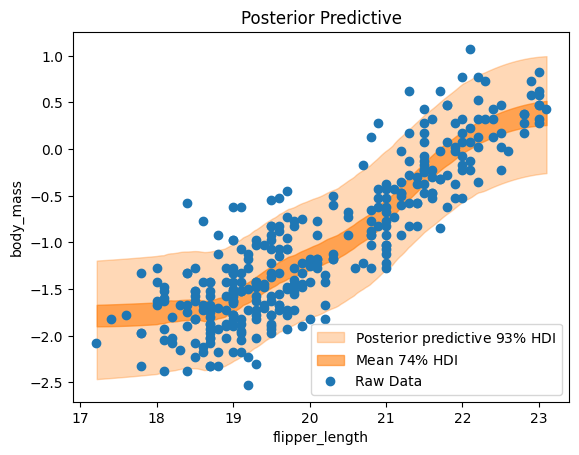

In [14]:
idx = np.argsort(X.to_numpy()[:, 0]) # grab flipper_length (index 0)
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0], # grab flipper_length (index 0)
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0], # grab flipper_length (index 0)
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(sdsts_nona['flipper_length'], Y, "o", c="C0", label="Raw Data") # Corrected column name
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

In [21]:
pm.sample_posterior_predictive(idata_penguins, model_penguins, extend_inferencedata=True)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

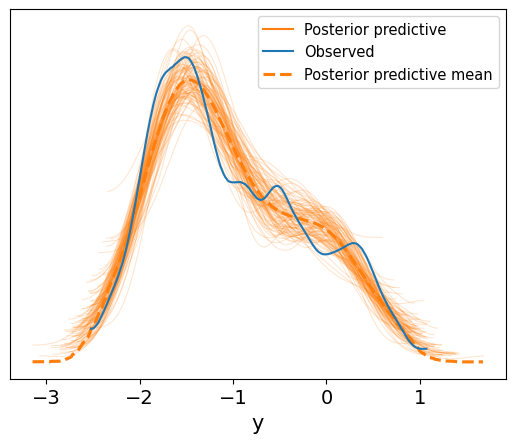

In [16]:
ax = az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])
#ax.set_xlim(0.0,0.0005)

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I do think it captures the true association. The model is very accurate and captures all of the data well. It captures the rising trend very accurately.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

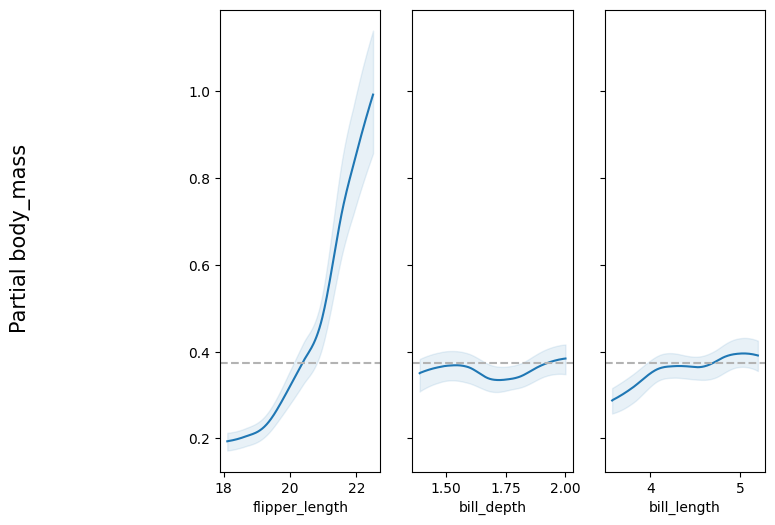

In [17]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

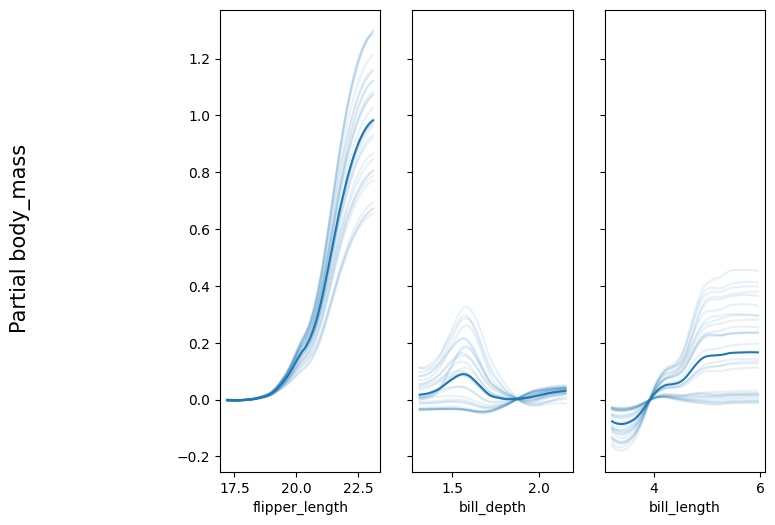

In [18]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [19]:
vi_gun = pmb.compute_variable_importance(idata_penguins, μ_, X)

<Axes: ylabel='R²'>

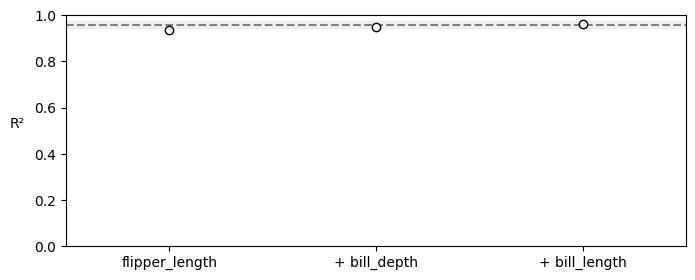

In [20]:
pmb.plot_variable_importance(vi_gun)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Based on the variable importance plot, bill length is slightly higher than bill depth and flipper length. Based on the ice plot and pdp plot, the results are pretty similar, flipper length is distinct from the the other factors.

Flipper length has a proportional relationship with body mass, while bill depth oscillates and bill length is also pretty proportional.

Yes, as you can see in the ICE and PDP plot that the different interactions are affecting the variables.